<a href="https://colab.research.google.com/github/rahna1369/ABC-Company-Workforce-Analysis/blob/main/india_weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.cluster import KMeans
from statsmodels.tsa.arima.model import ARIMA

# DATA PREPROCESSING & EDA


## 1. Data Loading & Inspection


In [ ]:
# Load the dataset
df = pd.read_csv("popular_cities_weather.csv")

In [ ]:
# Display the first 5 rows
print("--- FIRST 5 ROWS ---")
print(df.head())

--- FIRST 5 ROWS ---
                  date  tavg  tmin  tmax  prcp  wspd    pres     tsun    city
0  2020-01-01 00:00:00  24.9  19.2  29.9   0.0   NaN  1013.4  13800.0  Mumbai
1  2020-02-01 00:00:00  27.3  21.0  32.6   0.0   NaN  1012.7  11220.0  Mumbai
2  2020-03-01 00:00:00  27.7  22.6  31.9   0.0   NaN  1011.2  12900.0  Mumbai
3  2020-04-01 00:00:00  30.2  26.4  33.9   0.0   NaN  1009.6  14220.0  Mumbai
4  2020-05-01 00:00:00  31.1  28.6  34.0   0.0   NaN  1007.3  15960.0  Mumbai


In [ ]:
# Check the total number of rows & columns
print(df.shape)

(7056, 9)


In [ ]:
# Column names
print(df.columns)

Index(['date', 'tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres', 'tsun', 'city'], dtype='object')


In [ ]:
# Cities names
df["city"].unique()

array(['Mumbai', 'Delhi', 'Bengaluru', 'Ahmedabad', 'Hyderabad',
       'Chennai', 'Kolkata', 'Pune', 'Jaipur', 'Surat', 'Lucknow',
       'Kanpur', 'Nagpur', 'Patna', 'Indore', 'Thane', 'Bhopal',
       'Visakhapatnam', 'Vadodara', 'Firozabad', 'Ludhiana', 'Rajkot',
       'Agra', 'Siliguri', 'Nashik', 'Faridabad', 'Patiala', 'Meerut',
       'Kalyan-Dombivli', 'Vasai-Virar', 'Varanasi', 'Srinagar',
       'Dhanbad', 'Jodhpur', 'Amritsar', 'Raipur', 'Allahabad',
       'Coimbatore', 'Jabalpur', 'Gwalior', 'Vijayawada', 'Madurai',
       'Guwahati', 'Chandigarh', 'Amroha', 'Moradabad', 'Gurgaon',
       'Aligarh', 'Solapur', 'Ranchi', 'Jalandhar', 'Tiruchirappalli',
       'Bhubaneswar', 'Salem', 'Warangal', 'Thiruvananthapuram',
       'Bhiwandi', 'Saharanpur', 'Guntur', 'Amravati', 'Bikaner', 'Noida',
       'Jamshedpur', 'Bhilai', 'Cuttack', 'Firozpur', 'Kochi', 'Nellore',
       'Bhavnagar', 'Dehradun', 'Durgapur', 'Asansol', 'Rourkela',
       'Nanded', 'Kolhapur', 'Ajmer', 'Akola

In [ ]:
# Check data types, non-null counts, and memory usage of the dataset
print("--- DATASET SUMMARY ---")
print(df.info())

--- DATASET SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    7056 non-null   object 
 1   tavg    6517 non-null   float64
 2   tmin    6452 non-null   float64
 3   tmax    6431 non-null   float64
 4   prcp    6126 non-null   float64
 5   wspd    0 non-null      float64
 6   pres    6434 non-null   float64
 7   tsun    2405 non-null   float64
 8   city    7056 non-null   object 
dtypes: float64(7), object(2)
memory usage: 496.3+ KB
None


In [ ]:
# Descriptive statistical analysis
print("\n--- DESCRIPTIVE STATISTICS ---")
print(df.describe())


--- DESCRIPTIVE STATISTICS ---
              tavg         tmin         tmax         prcp  wspd         pres  \
count  6517.000000  6452.000000  6431.000000  6126.000000   0.0  6434.000000   
mean     25.896179    20.843971    31.630944   117.887055   NaN  1008.847606   
std       5.220012     5.724433     5.035931   180.628768   NaN     5.308233   
min       0.600000    -4.500000     5.700000     0.000000   NaN   994.800000   
25%      23.300000    17.200000    29.300000     3.000000   NaN  1004.400000   
50%      27.100000    22.600000    32.000000    45.000000   NaN  1009.200000   
75%      29.500000    25.300000    34.700000   169.500000   NaN  1013.300000   
max      36.600000    31.000000    44.000000  1768.900000   NaN  1025.900000   

               tsun  
count   2405.000000  
mean   10584.997921  
std     3864.452460  
min     1020.000000  
25%     7680.000000  
50%    10740.000000  
75%    13620.000000  
max    21360.000000  


## 2. Handling Missing Values


#### 2.1: Counting Missing Values

In [ ]:
# check the total no.of missing null values in each column
print("\n--- MISSING VALUE COUNT PER COLUMN ---")
print(df.isnull().sum())


--- MISSING VALUE COUNT PER COLUMN ---
date       0
tavg     539
tmin     604
tmax     625
prcp     930
wspd    7056
pres     622
tsun    4651
city       0
dtype: int64


In [ ]:
# Calculate the percentage of missing data
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\n--- Percentage of Missing Data ---")
print(missing_percentage)


--- Percentage of Missing Data ---
date      0.000000
tavg      7.638889
tmin      8.560091
tmax      8.857710
prcp     13.180272
wspd    100.000000
pres      8.815193
tsun     65.915533
city      0.000000
dtype: float64


In [ ]:
# check the total no.of missing null values in each rows
print("\n--- MISSING VALUE COUNT PER ROws ---")
print(df.isnull().sum(axis=1))


--- MISSING VALUE COUNT PER ROws ---
0       1
1       1
2       1
3       1
4       1
       ..
7051    2
7052    2
7053    2
7054    2
7055    2
Length: 7056, dtype: int64


In [ ]:
# Calculate percentage of missing data in each row
missing_row_pct = (df.isnull().mean(axis=1) * 100).round(2)

# Show the top 10 rows with the highest percentage of missing data
print("Missing values from row in highest Percentage ")
missing_row_pct.sort_values(ascending=False).head(10)

Missing values from row in highest Percentage 


,0
4761,77.78
6995,77.78
6994,77.78
4756,77.78
4752,77.78
4598,77.78
4591,77.78
4547,77.78
4546,77.78
4545,77.78


#### 2.3: Visualizing Missing Data using Heatmap

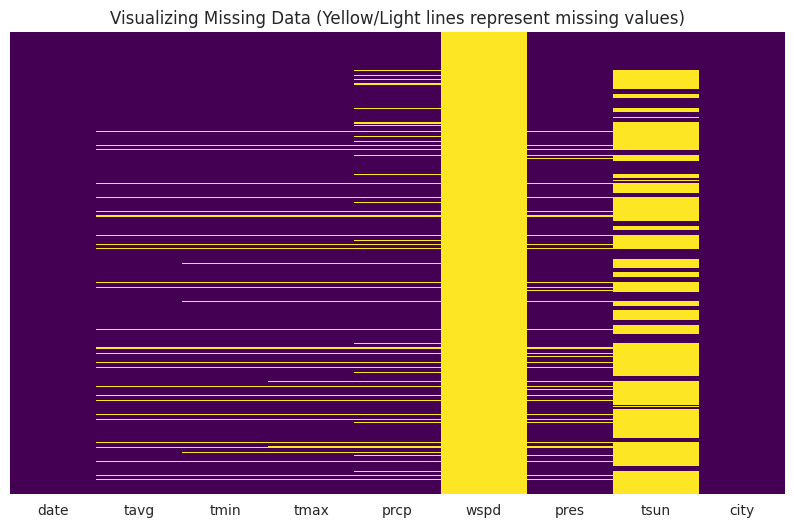

In [ ]:
# Create a heatmap of missing values
plt.figure(figsize=(10, 6))

# cbar=False removes the color bar legend, yticklabels=False hides individual row numbers for clarity
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Visualizing Missing Data (Yellow/Light lines represent missing values)")
plt.show()

## 3. Visualizing Data Distribution Analysis

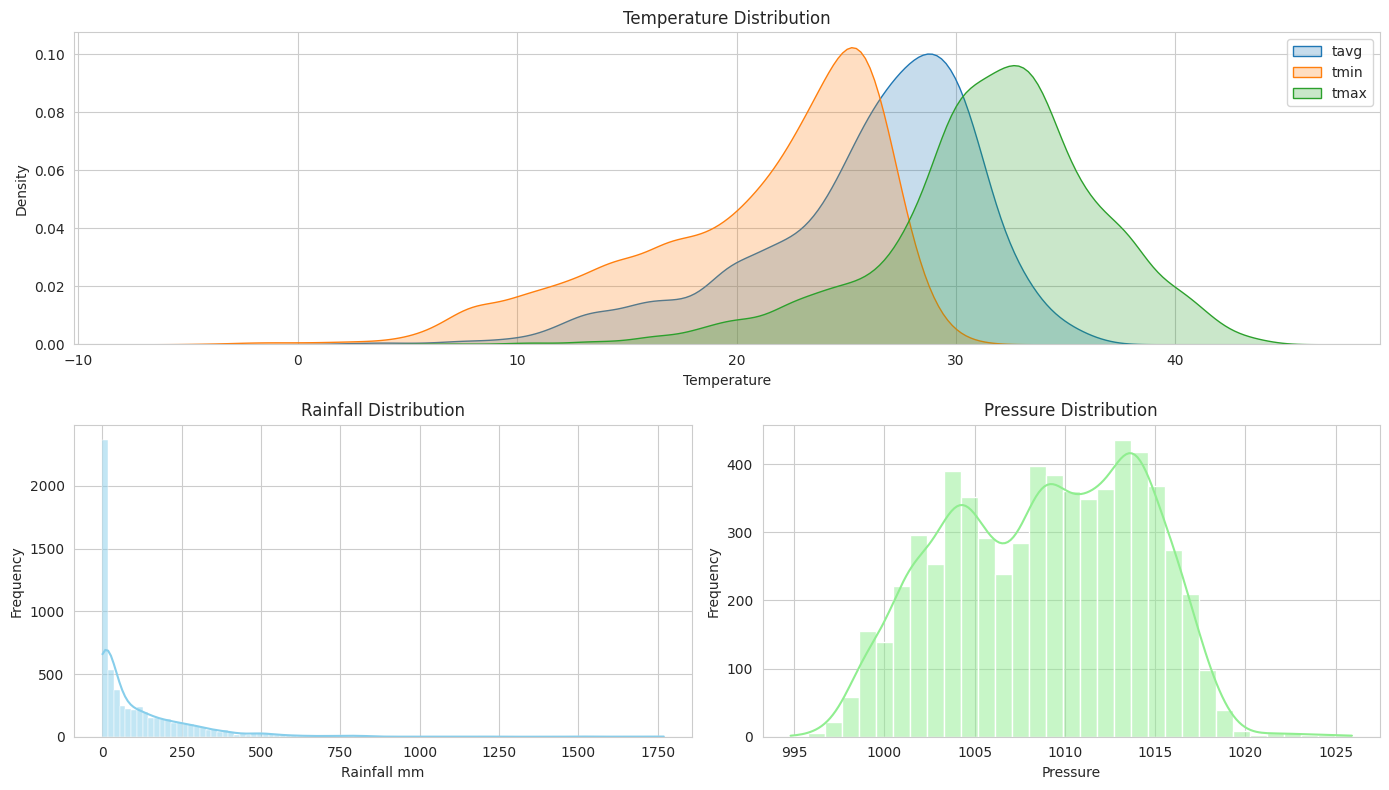

In [ ]:
sns.set_style("whitegrid")

fig = plt.figure(figsize=(14, 8))

# Temperature distribution
plt.subplot(2, 1, 1)
sns.kdeplot(df["tavg"], label="tavg", fill=True)
sns.kdeplot(df["tmin"], label="tmin", fill=True)
sns.kdeplot(df["tmax"], label="tmax", fill=True)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Density")
plt.legend()

# Rainfall distribution
plt.subplot(2, 2, 3)
sns.histplot(df["prcp"], kde=True, color="skyblue")
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall mm")
plt.ylabel("Frequency")

# Pressure distribution
plt.subplot(2, 2, 4)
sns.histplot(df["pres"], kde=True, color="lightgreen")
plt.title("Pressure Distribution")
plt.xlabel("Pressure")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 4. Data Cleaning

#### 4.1: Removing Duplicates

In [ ]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove duplicate rows, keeping the first occurrence
df.drop_duplicates(inplace=True)

Duplicate rows: 144


#### 4.2: Drop Weak Columns & Rows

In [ ]:
# Drop the colums that have massive missing value
df.drop(columns=['wspd', 'tsun'], errors='ignore', inplace=True)

# Drop rows
df = df.dropna(subset=["tavg","prcp"])
print(df.shape)
df.head()


(5999, 7)


,date,tavg,tmin,tmax,prcp,pres,city
0,2020-01-01 00:00:00,24.9,19.2,29.9,0.0,1013.4,Mumbai
1,2020-02-01 00:00:00,27.3,21.0,32.6,0.0,1012.7,Mumbai
2,2020-03-01 00:00:00,27.7,22.6,31.9,0.0,1011.2,Mumbai
3,2020-04-01 00:00:00,30.2,26.4,33.9,0.0,1009.6,Mumbai
4,2020-05-01 00:00:00,31.1,28.6,34.0,0.0,1007.3,Mumbai


#### 4.3: Data type formatting

In [ ]:
# Convert the 'date' column to a proper datetime format
df['date'] = pd.to_datetime(df['date'])


#### 4.4: Feature Engineering


4.4.1: Data Extraction

In [ ]:
#  Feature Engineering: Extract Month and Year
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df.head()

,date,tavg,tmin,tmax,prcp,pres,city,year,month
0,2020-01-01,24.9,19.2,29.9,0.0,1013.4,Mumbai,2020,1
1,2020-02-01,27.3,21.0,32.6,0.0,1012.7,Mumbai,2020,2
2,2020-03-01,27.7,22.6,31.9,0.0,1011.2,Mumbai,2020,3
3,2020-04-01,30.2,26.4,33.9,0.0,1009.6,Mumbai,2020,4
4,2020-05-01,31.1,28.6,34.0,0.0,1007.3,Mumbai,2020,5


4.4.2: Visualizing Monthly Temperature

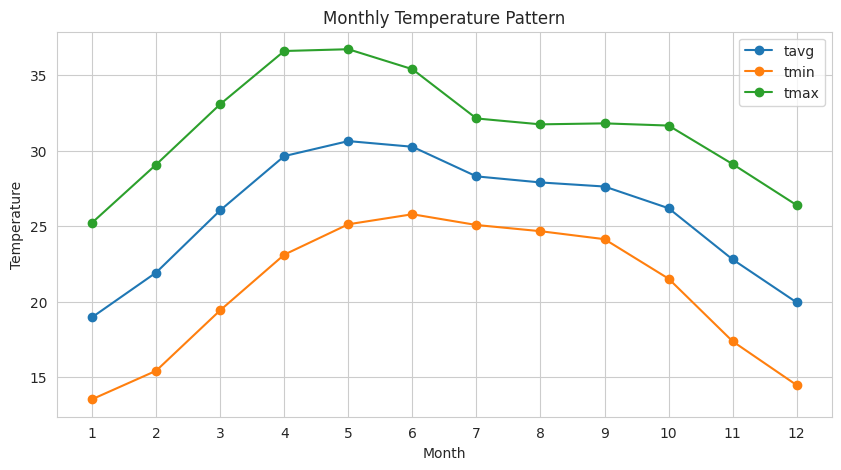

In [ ]:
monthly_temp = df.groupby("month")[["tavg", "tmin", "tmax"]].mean()

plt.figure(figsize=(10, 5))

plt.plot(monthly_temp.index, monthly_temp["tavg"], marker="o", label="tavg")
plt.plot(monthly_temp.index, monthly_temp["tmin"], marker="o", label="tmin")
plt.plot(monthly_temp.index, monthly_temp["tmax"], marker="o", label="tmax")

plt.title("Monthly Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.xticks(range(1, 13))
plt.legend()
plt.show()

4.4.3: Visualizing Monthly Average Rainfall

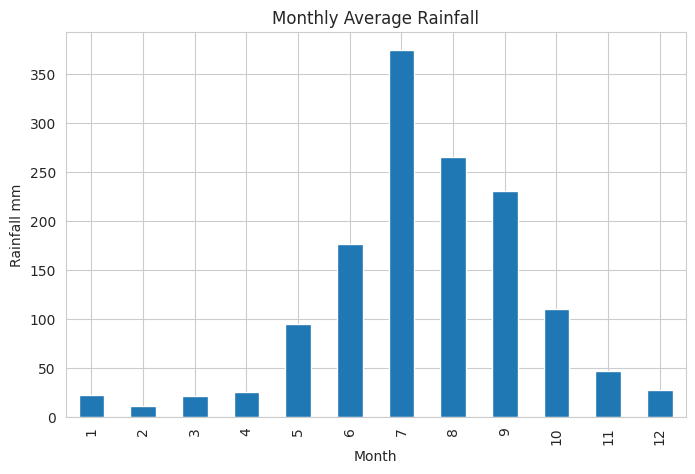

In [ ]:
monthly_rain = df.groupby("month")["prcp"].mean()

plt.figure(figsize=(8, 5))

monthly_rain.plot(kind="bar")

plt.title("Monthly Average Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall mm")
plt.show()

4.4.4: Encode Categorical Column

In [ ]:
# Initialize the LabelEncoder
encoder = LabelEncoder()
# Convert the text city column into numeric code
df["city_encoded"] = encoder.fit_transform(df["city"])
df.head()

,date,tavg,tmin,tmax,prcp,pres,city,year,month,city_encoded
0,2020-01-01,24.9,19.2,29.9,0.0,1013.4,Mumbai,2020,1,62
1,2020-02-01,27.3,21.0,32.6,0.0,1012.7,Mumbai,2020,2,62
2,2020-03-01,27.7,22.6,31.9,0.0,1011.2,Mumbai,2020,3,62
3,2020-04-01,30.2,26.4,33.9,0.0,1009.6,Mumbai,2020,4,62
4,2020-05-01,31.1,28.6,34.0,0.0,1007.3,Mumbai,2020,5,62


In [ ]:
# Binary Encoding for precipitation
df["rain_status"] = np.where(df["prcp"] > 0, 1, 0)

print(df[["prcp", "rain_status"]].head())

   prcp  rain_status
0   0.0            0
1   0.0            0
2   0.0            0
3   0.0            0
4   0.0            0


4.4.5: Visualizing Top 10 Hottest Cities

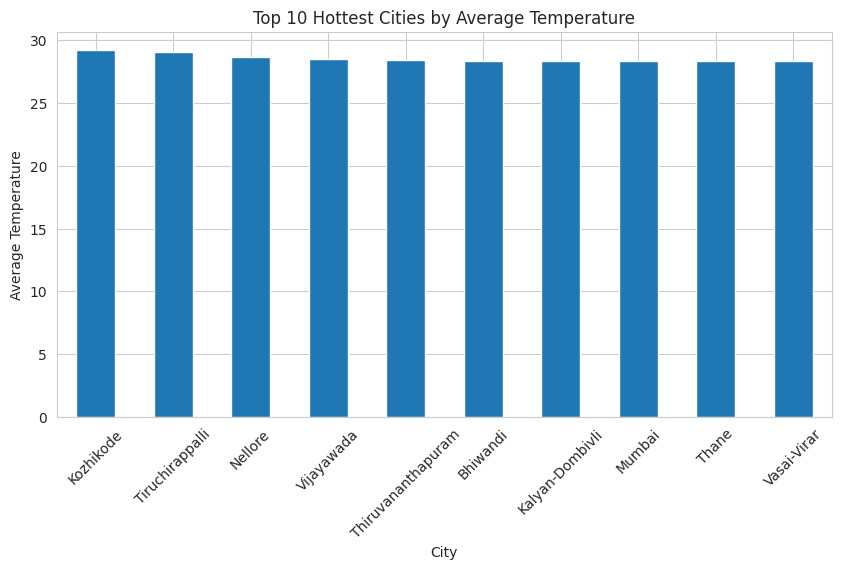

In [ ]:
top_hot_cities = df.groupby("city")["tavg"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))

top_hot_cities.plot(kind="bar")

plt.title("Top 10 Hottest Cities by Average Temperature")
plt.xlabel("City")
plt.ylabel("Average Temperature")
plt.xticks(rotation=45)
plt.show()

4.4.6: Visualizing Top 10 Rainiest Cities

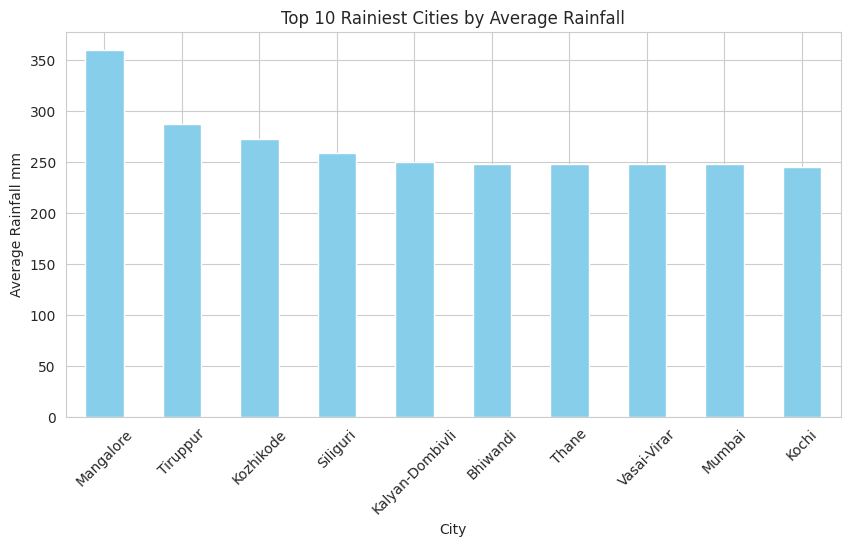

In [ ]:
top_rainy_cities = df.groupby("city")["prcp"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))

top_rainy_cities.plot(kind="bar", color="skyblue")

plt.title("Top 10 Rainiest Cities by Average Rainfall")
plt.xlabel("City")
plt.ylabel("Average Rainfall mm")
plt.xticks(rotation=45)
plt.show()

###4.5: Median Imputatiom

In [ ]:
missing_value_cols = ["tmin", "tmax", "prcp", "pres"]

df[missing_value_cols] = df[missing_value_cols].fillna(
    df[missing_value_cols].median()
)
df

,date,tavg,tmin,tmax,prcp,pres,city,year,month,city_encoded,rain_status
0,2020-01-01,24.9,19.2,29.9,0.0,1013.4,Mumbai,2020,1,62,0
1,2020-02-01,27.3,21.0,32.6,0.0,1012.7,Mumbai,2020,2,62,0
2,2020-03-01,27.7,22.6,31.9,0.0,1011.2,Mumbai,2020,3,62,0
3,2020-04-01,30.2,26.4,33.9,0.0,1009.6,Mumbai,2020,4,62,0
4,2020-05-01,31.1,28.6,34.0,0.0,1007.3,Mumbai,2020,5,62,0
...,...,...,...,...,...,...,...,...,...,...,...
7051,2025-08-01,20.8,18.0,24.8,321.1,1007.4,Shimla,2025,8,78,1
7052,2025-09-01,19.8,16.3,24.3,150.9,1009.4,Shimla,2025,9,78,1
7053,2025-10-01,15.9,10.6,22.6,61.5,1015.1,Shimla,2025,10,78,1
7054,2025-11-01,11.6,6.1,19.4,2.4,1017.8,Shimla,2025,11,78,1


## 5. Outlier Detection & Handling

### 5.1: Outlier Detection Before Handling (Boxplot)

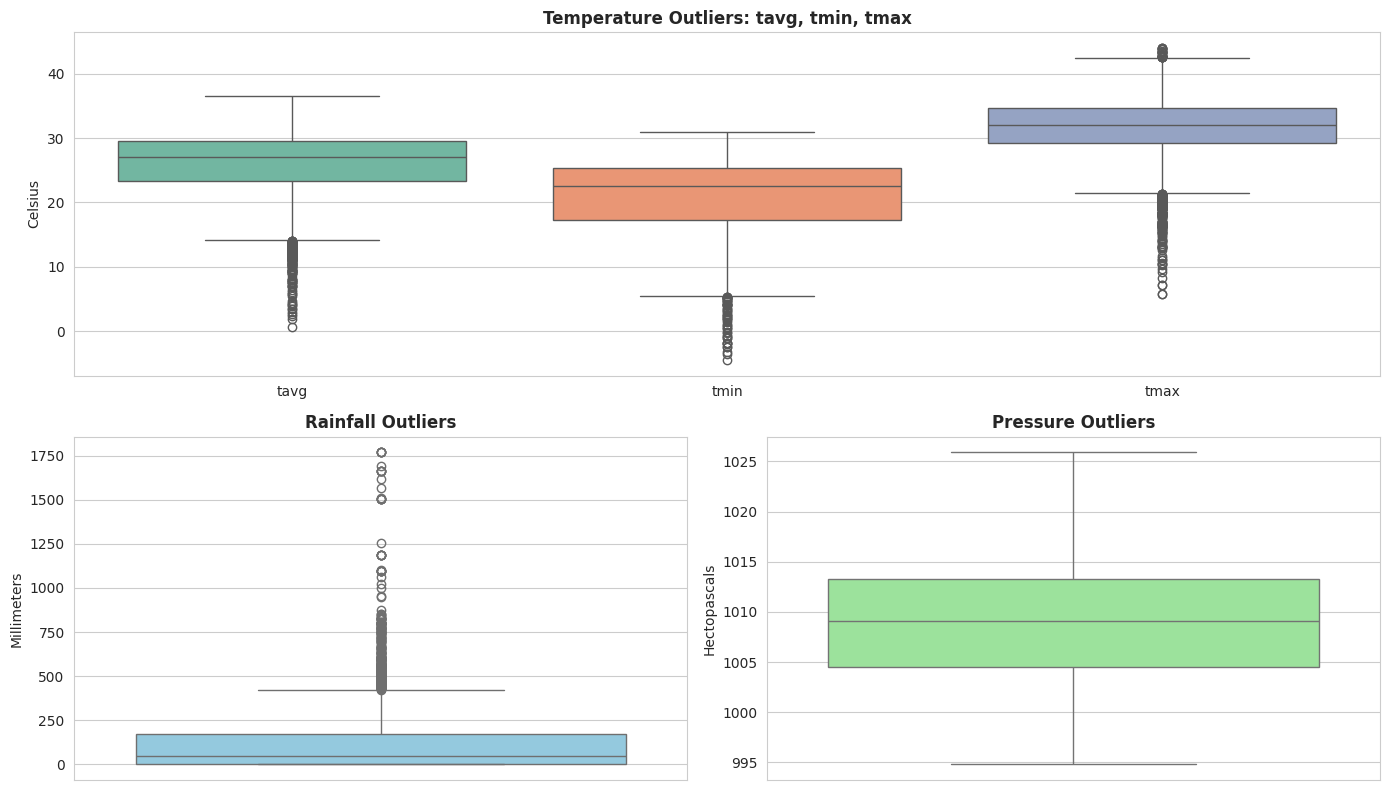

In [ ]:
sns.set_style("whitegrid")

fig = plt.figure(figsize=(14, 8))

# Temperature plot - full width
plt.subplot(2, 1, 1)
sns.boxplot(data=df[["tavg", "tmin", "tmax"]], palette="Set2")
plt.title("Temperature Outliers: tavg, tmin, tmax", fontweight="bold")
plt.ylabel("Celsius")

# Rainfall plot
plt.subplot(2, 2, 3)
sns.boxplot(y=df["prcp"], color="skyblue")
plt.title("Rainfall Outliers", fontweight="bold")
plt.ylabel("Millimeters")

# Pressure plot
plt.subplot(2, 2, 4)
sns.boxplot(y=df["pres"], color="lightgreen")
plt.title("Pressure Outliers", fontweight="bold")
plt.ylabel("Hectopascals")

plt.tight_layout()
plt.show()

###5.2: Handle Outliers using IQR capping

In [ ]:
# Define the function to cap outliers for Temperature and Pressure
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[column] = np.where(data[column] < lower_limit, lower_limit, data[column])
    data[column] = np.where(data[column] > upper_limit, upper_limit, data[column])

    return data

outlier_columns = ["tavg", "tmin", "tmax", "prcp", "pres"]

for col in outlier_columns:
    df = cap_outliers_iqr(df, col)

print("Outlier handling completed.")

Outlier handling completed.


### 5.3: Handling outliers using log transformation(Skewed Data)


In [ ]:
df["prcp_log"] = np.log1p(df["prcp"])

print("Rainfall skewness before log:", df["prcp"].skew())
print("Rainfall skewness after log:", df["prcp_log"].skew())

Rainfall skewness before log: 1.217246674265326
Rainfall skewness after log: -0.38771307984985415


### 5.4: Visualization Before and after log transformation(Histogram)

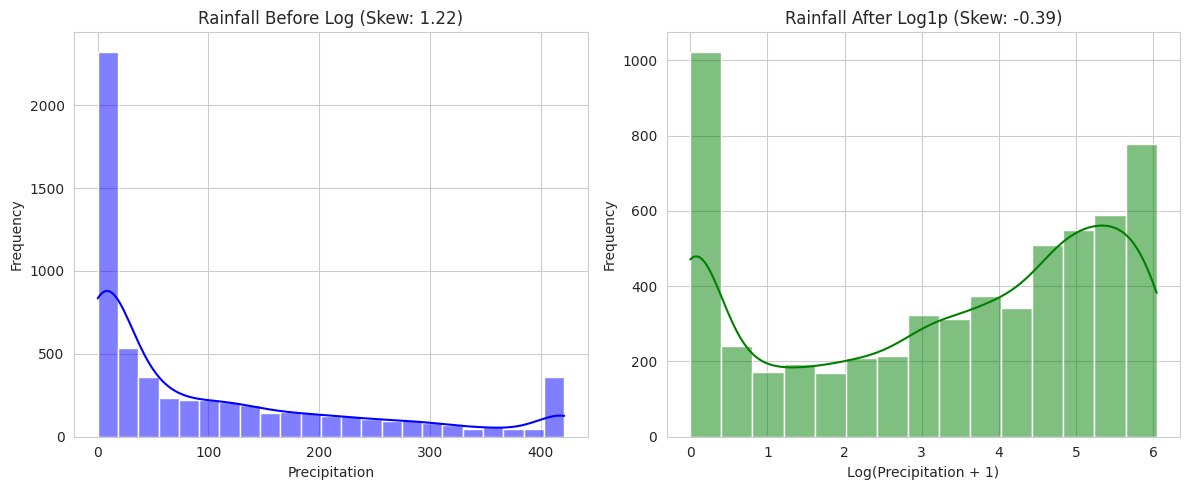

In [ ]:
# Set up a 1-row, 2-column plotting area
plt.figure(figsize=(12, 5))

# 1. Left Subplot: Before Transformation
plt.subplot(1, 2, 1)
sns.histplot(df["prcp"], kde=True, color="blue")
plt.title(f'Rainfall Before Log (Skew: {df["prcp"].skew():.2f})')
plt.xlabel("Precipitation")
plt.ylabel("Frequency")

# 2. Right Subplot: After Log Transformation
plt.subplot(1, 2, 2)
sns.histplot(df["prcp_log"], kde=True, color="green")
plt.title(f'Rainfall After Log1p (Skew: {df["prcp_log"].skew():.2f})')
plt.xlabel("Log(Precipitation + 1)")
plt.ylabel("Frequency")

# Adjust spacing and display
plt.tight_layout()
plt.show()

###5.5:  Outlier Detection After Handling (Boxplot)

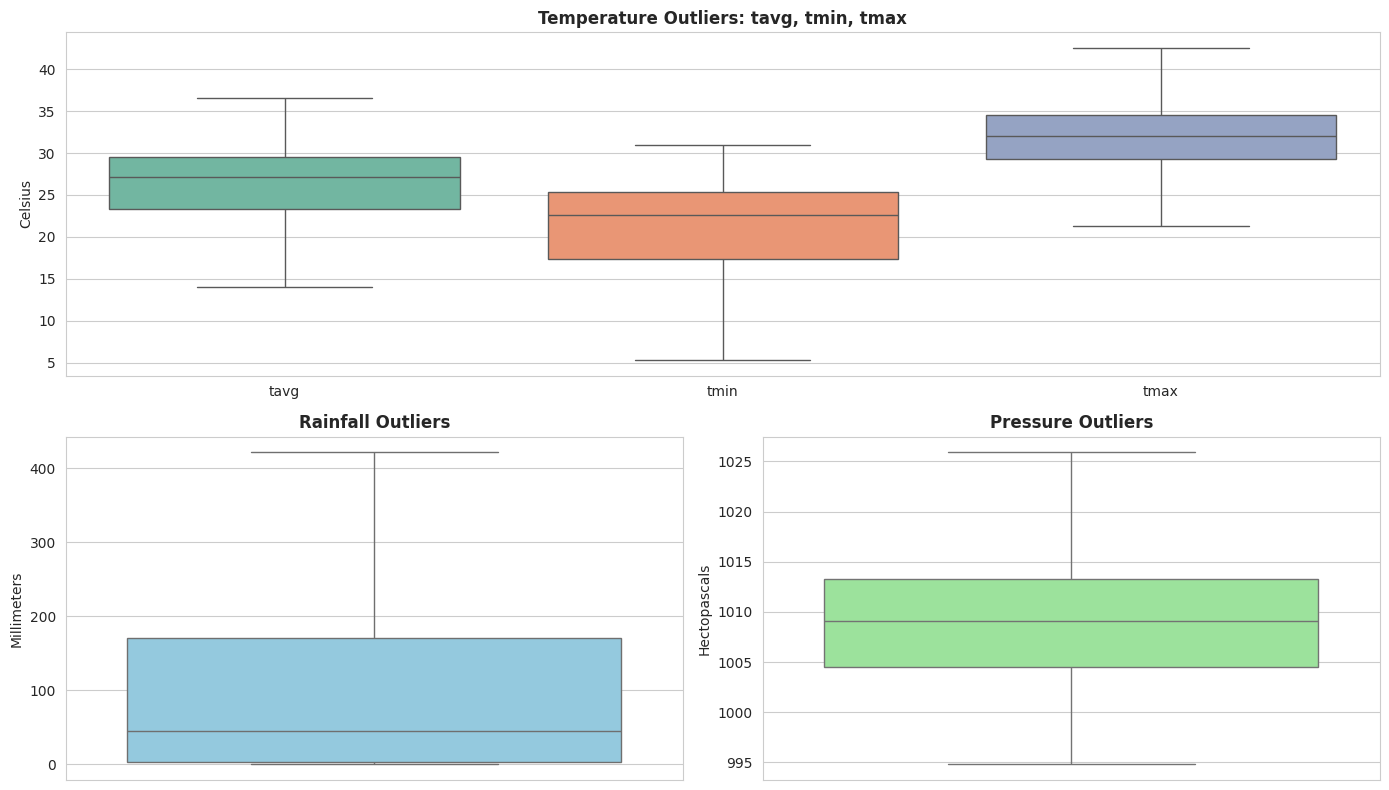

In [ ]:
sns.set_style("whitegrid")

fig = plt.figure(figsize=(14, 8))

# Temperature plot - full width
plt.subplot(2, 1, 1)
sns.boxplot(data=df[["tavg", "tmin", "tmax"]], palette="Set2")
plt.title("Temperature Outliers: tavg, tmin, tmax", fontweight="bold")
plt.ylabel("Celsius")

# Rainfall plot
plt.subplot(2, 2, 3)
sns.boxplot(y=df["prcp"], color="skyblue")
plt.title("Rainfall Outliers", fontweight="bold")
plt.ylabel("Millimeters")

# Pressure plot
plt.subplot(2, 2, 4)
sns.boxplot(y=df["pres"], color="lightgreen")
plt.title("Pressure Outliers", fontweight="bold")
plt.ylabel("Hectopascals")

plt.tight_layout()
plt.show()

## 6. Feature Selection

###6.1: Correlation (Heatmap)

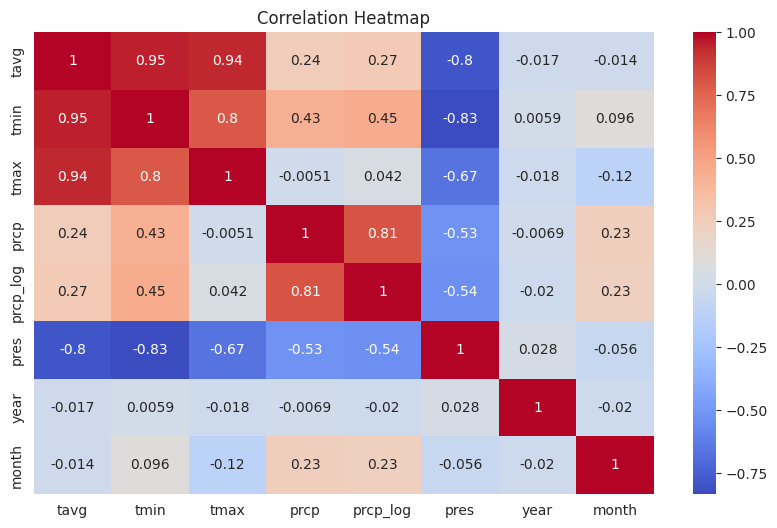

In [ ]:
corr_cols = [
    "tavg",
    "tmin",
    "tmax",
    "prcp",
    "prcp_log",
    "pres",
    "year",
    "month"
]
plt.figure(figsize=(10, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## 7. Splitting Data into Training and Testing sets

###7.1: Split data for temperature prediction

In [ ]:
temperature_features = [
    "tmin",
    "tmax",
    "prcp_log",
    "pres",
    "city_encoded",
    "year",
    "month"
]

X_temp = df[temperature_features]
y_temp = df["tavg"]

X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=42
)

print("Temperature Train:", X_train_temp.shape)
print("Temperature Test:", X_test_temp.shape)

Temperature Train: (4799, 7)
Temperature Test: (1200, 7)


###7.2: Split data for rainfall amount prediction

In [ ]:
rainfall_features = [
    "tavg",
    "tmin",
    "tmax",
    "pres",
    "city_encoded",
    "year",
    "month"
]

X_rain = df[rainfall_features]
y_rain = df["prcp_log"]

X_train_rain, X_test_rain, y_train_rain, y_test_rain = train_test_split(
    X_rain,
    y_rain,
    test_size=0.2,
    random_state=42
)

print("Rainfall Train:", X_train_rain.shape)
print("Rainfall Test:", X_test_rain.shape)

Rainfall Train: (4799, 7)
Rainfall Test: (1200, 7)


###7.3: Split data for Rain / No Rain classification

In [ ]:
df["rain_status"] = np.where(df["prcp"] > 0, 1, 0)

classification_features = [
    "tavg",
    "tmin",
    "tmax",
    "pres",
    "city_encoded",
    "year",
    "month"
]

X_class = df[classification_features]
y_class = df["rain_status"]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Classification Train:", X_train_class.shape)
print("Classification Test:", X_test_class.shape)

Classification Train: (4799, 7)
Classification Test: (1200, 7)


## 8. Feature Scaling

In [ ]:
# Temperature scaling
temp_scaler = StandardScaler()
X_train_temp_scaled = temp_scaler.fit_transform(X_train_temp)
X_test_temp_scaled = temp_scaler.transform(X_test_temp)

# Rainfall regression scaling
rain_scaler = StandardScaler()
X_train_rain_scaled = rain_scaler.fit_transform(X_train_rain)
X_test_rain_scaled = rain_scaler.transform(X_test_rain)

# Rain / No Rain classification scaling
class_scaler = StandardScaler()
X_train_class_scaled = class_scaler.fit_transform(X_train_class)
X_test_class_scaled = class_scaler.transform(X_test_class)

print("Complete Feature scaling.")


Complete Feature scaling.


# MODEL BULIDING & TRAINING

## 9. Supervised Learning Model

### 9.1: Temperature Models Training

In [ ]:
# Linear Regression for temperature
lr_temp_model = LinearRegression()
lr_temp_model.fit(X_train_temp_scaled, y_train_temp)

# Random Forest Regressor for temperature
rf_temp_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_temp_model.fit(X_train_temp, y_train_temp)

print("Temperature models trained successfully.")

# Temperature predictions
lr_temp_pred = lr_temp_model.predict(X_test_temp_scaled)
rf_temp_pred = rf_temp_model.predict(X_test_temp)

print("Prediction completed successfully.")


Temperature models trained successfully.
Prediction completed successfully.


###9.2: Rainfall Amount Models Training

In [ ]:
# Linear Regression for rainfall amount
lr_rain_model = LinearRegression()
lr_rain_model.fit(X_train_rain_scaled, y_train_rain)

# Random Forest Regressor for rainfall amount
rf_rain_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf_rain_model.fit(X_train_rain, y_train_rain)

print("Rainfall regression models trained successfully.")

# Rainfall predictions in log scale
lr_rain_pred_log = lr_rain_model.predict(X_test_rain_scaled)
rf_rain_pred_log = rf_rain_model.predict(X_test_rain)

# Convert rainfall prediction from log scale back to mm
lr_rain_pred_mm = np.expm1(lr_rain_pred_log)
rf_rain_pred_mm = np.expm1(rf_rain_pred_log)

# Actual rainfall in mm
rain_actual_mm = np.expm1(y_test_rain)

print("Prediction completed successfully.")



Rainfall regression models trained successfully.
Prediction completed successfully.


###9.3:  Rain / No Rain Classification Models

In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_class_scaled, y_train_class)

# Random Forest Classifier
rain_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rain_classifier.fit(X_train_class, y_train_class)

print("Rain / No Rain classification models trained successfully.")

# Rain / No Rain classification predictions
log_pred = log_model.predict(X_test_class_scaled)
rf_class_pred = rain_classifier.predict(X_test_class)

print("Prediction completed successfully.")

Rain / No Rain classification models trained successfully.
Prediction completed successfully.


## 10. Ealuate Model

###10.1: Evaluate Temperature Models

In [ ]:
# Linear Regression evaluation
lr_temp_mae = mean_absolute_error(y_test_temp, lr_temp_pred)
lr_temp_rmse = np.sqrt(mean_squared_error(y_test_temp, lr_temp_pred))
lr_temp_r2 = r2_score(y_test_temp, lr_temp_pred)


# Random Forest evaluation
rf_temp_mae = mean_absolute_error(y_test_temp, rf_temp_pred)
rf_temp_rmse = np.sqrt(mean_squared_error(y_test_temp, rf_temp_pred))
rf_temp_r2 = r2_score(y_test_temp, rf_temp_pred)


print("Linear Regression Temperature Evaluation")
print("MAE:", lr_temp_mae)
print("RMSE:", lr_temp_rmse)
print("R2 Score:", lr_temp_r2)

print("\nRandom Forest Temperature Evaluation")
print("MAE:", rf_temp_mae)
print("RMSE:", rf_temp_rmse)
print("R2 Score:", rf_temp_r2)

Linear Regression Temperature Evaluation
MAE: 0.30988000841926794
RMSE: 0.38359201216163613
R2 Score: 0.9936861230749892

Random Forest Temperature Evaluation
MAE: 0.24408583333333245
RMSE: 0.33305615454954973
R2 Score: 0.9952401646621295


#### 10.1.1 Temperature Model Comparison

In [ ]:
temperature_results = pd.DataFrame({"Model": ["Linear Regression", "Random Forest"],
    "MAE": [ lr_temp_mae, rf_temp_mae ],
    "RMSE": [ lr_temp_rmse,  rf_temp_rmse ],
    "R2 Score": [ lr_temp_r2, rf_temp_r2 ]
})

print("Temperature Model Comparison")
print(temperature_results)

Temperature Model Comparison
               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.309880  0.383592  0.993686
1      Random Forest  0.244086  0.333056  0.995240


#### 10.1.2: Best temperature model

In [ ]:
best_temp_model = temperature_results.sort_values(
    by="RMSE",
    ascending=True
).iloc[0]

print("Best Temperature Model:")
print(best_temp_model)

Best Temperature Model:
Model       Random Forest
MAE              0.244086
RMSE             0.333056
R2 Score          0.99524
Name: 1, dtype: object


#### 10.1.3: Temperature actual vs predicted

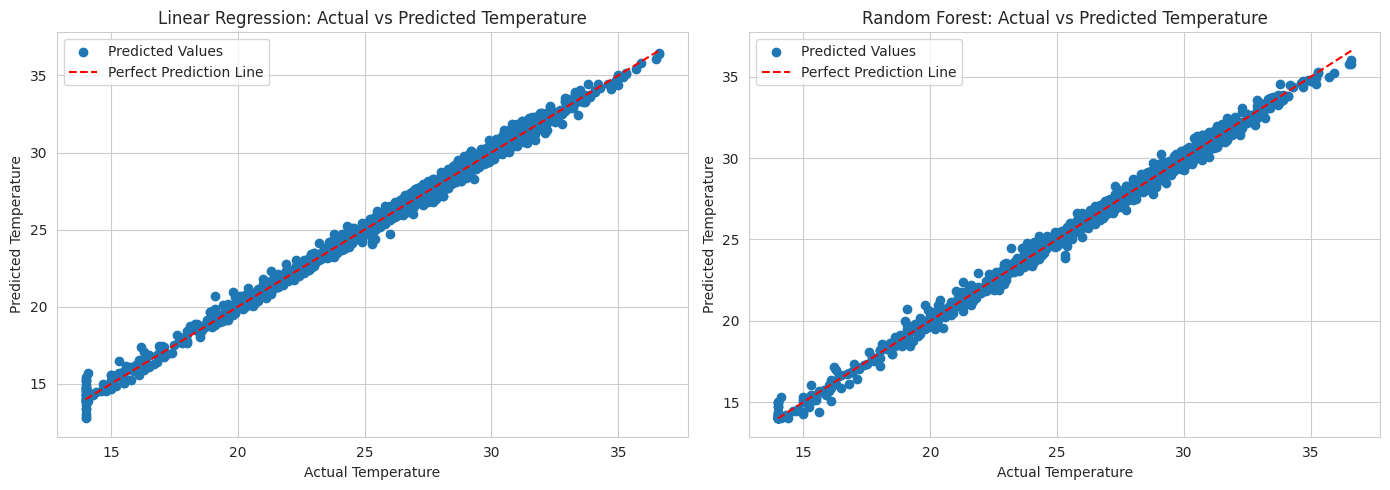

In [ ]:
plt.figure(figsize=(14, 5))

# Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test_temp, lr_temp_pred, label="Predicted Values")
plt.plot(
    [y_test_temp.min(), y_test_temp.max()],
    [y_test_temp.min(), y_test_temp.max()],
    linestyle="--",
    color="red",
    label="Perfect Prediction Line"
)
plt.title("Linear Regression: Actual vs Predicted Temperature")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.legend()

# Random Forest
plt.subplot(1, 2, 2)
plt.scatter(y_test_temp, rf_temp_pred, label="Predicted Values")
plt.plot(
    [y_test_temp.min(), y_test_temp.max()],
    [y_test_temp.min(), y_test_temp.max()],
    linestyle="--",
    color="red",
    label="Perfect Prediction Line"
)
plt.title("Random Forest: Actual vs Predicted Temperature")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.legend()

plt.tight_layout()
plt.show()

###10.2: Evaluate Rainfall Models

In [ ]:
# Linear Regression rainfall evaluation
lr_rain_mae = mean_absolute_error(rain_actual_mm, lr_rain_pred_mm)
lr_rain_rmse = np.sqrt(mean_squared_error(rain_actual_mm, lr_rain_pred_mm))
lr_rain_r2 = r2_score(y_test_rain, lr_rain_pred_log)


# Random Forest rainfall evaluation
rf_rain_mae = mean_absolute_error(rain_actual_mm, rf_rain_pred_mm)
rf_rain_rmse = np.sqrt(mean_squared_error(rain_actual_mm, rf_rain_pred_mm))
rf_rain_r2 = r2_score(y_test_rain, rf_rain_pred_log)


print("Linear Regression Rainfall Evaluation")
print("MAE:", lr_rain_mae)
print("RMSE:", lr_rain_rmse)
print("R2 Score:", lr_rain_r2)

print("\nRandom Forest Rainfall Evaluation")
print("MAE:", rf_rain_mae)
print("RMSE:", rf_rain_rmse)
print("R2 Score:", rf_rain_r2)

Linear Regression Rainfall Evaluation
MAE: 62.414077605635384
RMSE: 107.53945107653502
R2 Score: 0.5946672036519961

Random Forest Rainfall Evaluation
MAE: 34.12266828567802
RMSE: 56.10439805369364
R2 Score: 0.8294577878485029


#### 10.2.1: Rainfall Amount Model Comparison

In [ ]:
rainfall_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_rain_mae,
        rf_rain_mae
    ],
    "RMSE": [
        lr_rain_rmse,
        rf_rain_rmse
    ],
    "R2 Score": [
        lr_rain_r2,
        rf_rain_r2
    ]
})

print("Rainfall Model Comparison")
print(rainfall_results)

Rainfall Model Comparison
               Model        MAE        RMSE  R2 Score
0  Linear Regression  62.414078  107.539451  0.594667
1      Random Forest  34.122668   56.104398  0.829458


####10.2.2: Best rainfall model

In [ ]:
best_rain_model = rainfall_results.sort_values(
    by="RMSE",
    ascending=True
).iloc[0]

print("Best Rainfall Model:")
print(best_rain_model)

Best Rainfall Model:
Model       Random Forest
MAE             34.122668
RMSE            56.104398
R2 Score         0.829458
Name: 1, dtype: object


####10.2.3: Rainfall actual vs predicted

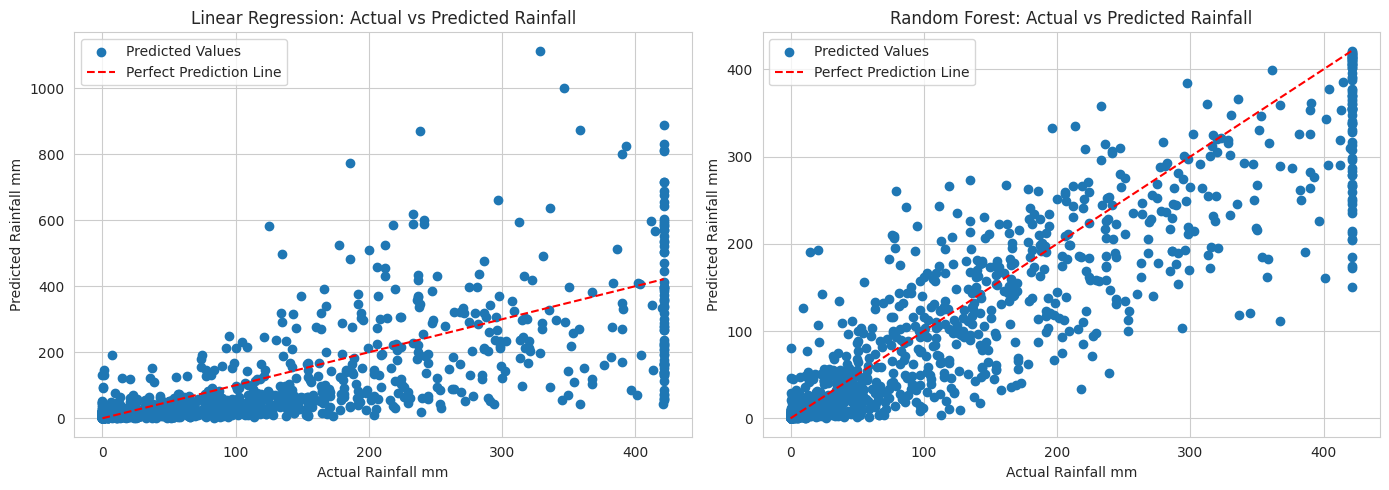

In [ ]:
plt.figure(figsize=(14, 5))

# Linear Regression Rainfall
plt.subplot(1, 2, 1)

plt.scatter(
    rain_actual_mm,
    lr_rain_pred_mm,
    label="Predicted Values"
)

plt.plot(
    [rain_actual_mm.min(), rain_actual_mm.max()],
    [rain_actual_mm.min(), rain_actual_mm.max()],
    linestyle="--",
    color="red",
    label="Perfect Prediction Line"
)

plt.title("Linear Regression: Actual vs Predicted Rainfall")
plt.xlabel("Actual Rainfall mm")
plt.ylabel("Predicted Rainfall mm")
plt.legend()


# Random Forest Rainfall
plt.subplot(1, 2, 2)

plt.scatter(
    rain_actual_mm,
    rf_rain_pred_mm,
    label="Predicted Values"
)

plt.plot(
    [rain_actual_mm.min(), rain_actual_mm.max()],
    [rain_actual_mm.min(), rain_actual_mm.max()],
    linestyle="--",
    color="red",
    label="Perfect Prediction Line"
)

plt.title("Random Forest: Actual vs Predicted Rainfall")
plt.xlabel("Actual Rainfall mm")
plt.ylabel("Predicted Rainfall mm")
plt.legend()

plt.tight_layout()
plt.show()

###10.3: Evaluate Classification Models

In [ ]:
# Logistic Regression accuracy
log_accuracy = accuracy_score(y_test_class, log_pred)

# Random Forest accuracy
rf_class_accuracy = accuracy_score(y_test_class, rf_class_pred)


print("Logistic Regression Rain / No Rain Evaluation")
print("Accuracy:", log_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test_class,
    log_pred,
    target_names=["No Rain", "Rain"]
))


print("\nRandom Forest Rain / No Rain Evaluation")
print("Accuracy:", rf_class_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test_class,
    rf_class_pred,
    target_names=["No Rain", "Rain"]
))

Logistic Regression Rain / No Rain Evaluation
Accuracy: 0.8616666666666667

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.58      0.15      0.24       173
        Rain       0.87      0.98      0.92      1027

    accuracy                           0.86      1200
   macro avg       0.73      0.57      0.58      1200
weighted avg       0.83      0.86      0.83      1200


Random Forest Rain / No Rain Evaluation
Accuracy: 0.9091666666666667

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.74      0.57      0.64       173
        Rain       0.93      0.97      0.95      1027

    accuracy                           0.91      1200
   macro avg       0.83      0.77      0.80      1200
weighted avg       0.90      0.91      0.90      1200



#### 10.3.1: Rain / No Rain Classification Model Comparison

In [ ]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest Classifier"
    ],
    "Accuracy": [
        log_accuracy,
        rf_class_accuracy
    ]
})

print("Rain / No Rain Classification Model Comparison")
print(classification_results)

Rain / No Rain Classification Model Comparison
                      Model  Accuracy
0       Logistic Regression  0.861667
1  Random Forest Classifier  0.909167


####10.3.2: Best classification model

In [ ]:
best_class_model = classification_results.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("Best Rain / No Rain Classification Model:")
print(best_class_model)

Best Rain / No Rain Classification Model:
Model       Random Forest Classifier
Accuracy                    0.909167
Name: 1, dtype: object


### 10.3.3: Confusion matrix

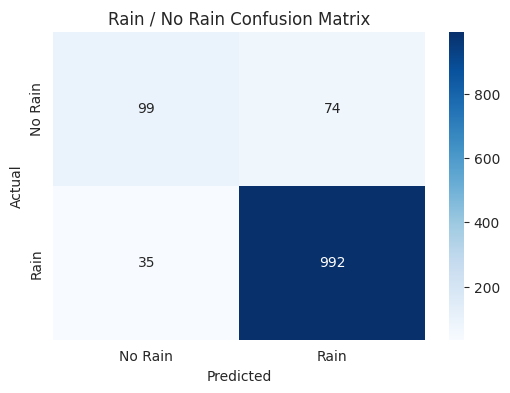

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(y_test_class, rf_class_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title("Rain / No Rain Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Regression models were evaluated using MAE, RMSE, and R2 score. MAE and RMSE measure prediction error, where lower values indicate better performance. R2 score measures how well the model explains the target variable, where a higher value is better.

Classification models were evaluated using accuracy, classification report, and confusion matrix. Accuracy shows the overall correct predictions, while precision, recall, and F1-score give deeper information about rain and no-rain prediction performance.

# 2026 PREDICTION & TIME-SERIES ANALYSIS

# 11. 2026 Future Dataset

In [ ]:
future_2026 = df.groupby(["city", "month"])[
    ["tavg", "tmin", "tmax", "prcp", "pres"]
].mean().reset_index()

future_2026["year"] = 2026
future_2026["city_encoded"] = encoder.transform(future_2026["city"])
future_2026["prcp_log"] = np.log1p(future_2026["prcp"])

future_2026["date"] = pd.to_datetime(
    future_2026["year"].astype(str) + "-" +
    future_2026["month"].astype(str) + "-01"
)

print(future_2026.head())

   city  month    tavg    tmin    tmax    prcp      pres  year  city_encoded  \
0  Agra      1  14.000   7.500  21.350  26.650  1017.700  2026             0   
1  Agra      2  18.260  11.220  26.160  17.380  1014.760  2026             0   
2  Agra      3  24.925  17.200  32.425  13.575  1011.050  2026             0   
3  Agra      4  30.720  22.420  38.080   2.760  1006.320  2026             0   
4  Agra      5  32.325  26.175  38.425  28.700  1002.625  2026             0   

   prcp_log       date  
0  3.319626 2026-01-01  
1  2.911263 2026-02-01  
2  2.679308 2026-03-01  
3  1.324419 2026-04-01  
4  3.391147 2026-05-01  


### 11.1: Predict 2026 Average Temperature

In [ ]:
X_future_temp = future_2026[temperature_features]

future_2026["predicted_tavg"] = rf_temp_model.predict(X_future_temp)

print(future_2026[["date", "city", "predicted_tavg"]].head())

        date  city  predicted_tavg
0 2026-01-01  Agra         14.0005
1 2026-02-01  Agra         18.5825
2 2026-03-01  Agra         24.6890
3 2026-04-01  Agra         30.2610
4 2026-05-01  Agra         32.3350


### 11.2: Predict 2026 Rainfall

In [ ]:


X_future_rain = future_2026[rainfall_features]

future_2026["predicted_rainfall_mm"] = np.expm1(
    rf_rain_model.predict(X_future_rain)
)

print(future_2026[["date", "city", "predicted_rainfall_mm"]].head())

        date  city  predicted_rainfall_mm
0 2026-01-01  Agra               9.773836
1 2026-02-01  Agra               1.901702
2 2026-03-01  Agra               6.633547
3 2026-04-01  Agra               3.414187
4 2026-05-01  Agra              46.264664


### 11.3: Predict 2026 Rain / No Rain

In [ ]:

X_future_class = future_2026[classification_features]

future_2026["rain_prediction"] = rain_classifier.predict(X_future_class)

future_2026["rain_prediction_label"] = future_2026["rain_prediction"].map({
    0: "No Rain",
    1: "Rain"
})

print(future_2026[
    ["date", "city", "predicted_tavg", "predicted_rainfall_mm", "rain_prediction_label"]
].head())

        date  city  predicted_tavg  predicted_rainfall_mm  \
0 2026-01-01  Agra         14.0005               9.773836   
1 2026-02-01  Agra         18.5825               1.901702   
2 2026-03-01  Agra         24.6890               6.633547   
3 2026-04-01  Agra         30.2610               3.414187   
4 2026-05-01  Agra         32.3350              46.264664   

  rain_prediction_label  
0                  Rain  
1                  Rain  
2                  Rain  
3                  Rain  
4                  Rain  


### 11.4 Kochi June 2026 Result

In [ ]:
kochi_june_2026 = future_2026[
    (future_2026["city"] == "Kochi") &
    (future_2026["month"] == 6)
]

print(kochi_june_2026[
    [
        "date",
        "city",
        "predicted_tavg",
        "predicted_rainfall_mm",
        "rain_prediction_label"
    ]
])

rainfall_value = kochi_june_2026["predicted_rainfall_mm"].values[0]

print("Predicted rainfall in Kochi for June 2026:", round(rainfall_value, 2), "mm")

          date   city  predicted_tavg  predicted_rainfall_mm  \
593 2026-06-01  Kochi         26.4045              395.69091   

    rain_prediction_label  
593                  Rain  
Predicted rainfall in Kochi for June 2026: 395.69 mm


#### 11.4.1: Kochi 2026 Visual

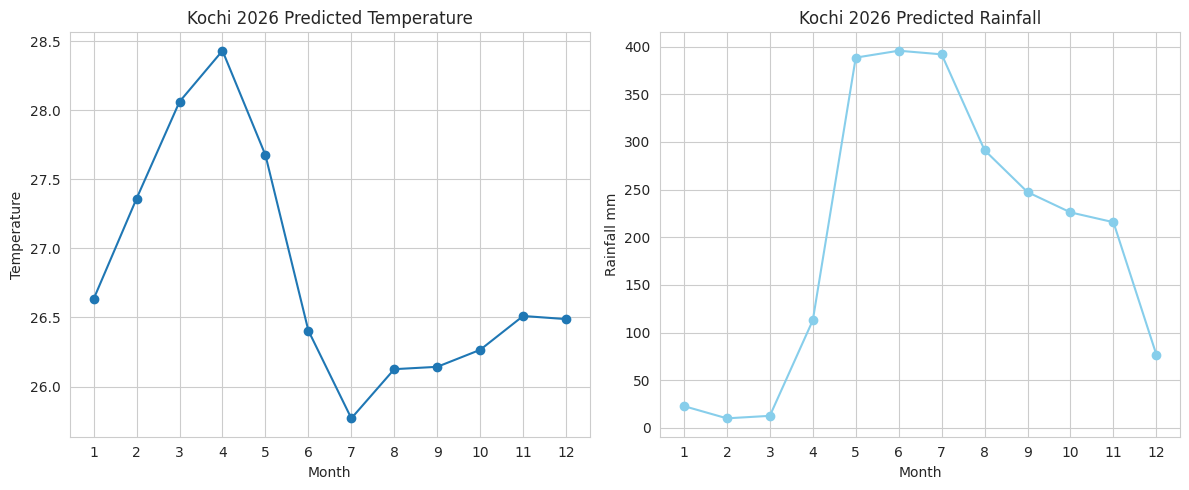

In [ ]:


kochi_2026 = future_2026[future_2026["city"] == "Kochi"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    kochi_2026["month"],
    kochi_2026["predicted_tavg"],
    marker="o"
)
plt.title("Kochi 2026 Predicted Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.xticks(range(1, 13))

plt.subplot(1, 2, 2)
plt.plot(
    kochi_2026["month"],
    kochi_2026["predicted_rainfall_mm"],
    marker="o",
    color="skyblue"
)
plt.title("Kochi 2026 Predicted Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall mm")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## 12. Unsupervised Machine Learning Model(Clustering)

### 12.1: Weather Data Clustering Analysis

In [ ]:
# Data Selection
cluster_data = df[
    [
        "tavg",
        "tmin",
        "tmax",
        "prcp_log",
        "pres"
    ]
]
# Feature Scaling
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

### 12.2: Fitting the K-Means Model and Assigning Cluster

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(cluster_scaled)

print(df[["city", "tavg", "prcp", "pres", "cluster"]].head())


     city  tavg  prcp    pres  cluster
0  Mumbai  24.9   0.0  1013.4        2
1  Mumbai  27.3   0.0  1012.7        2
2  Mumbai  27.7   0.0  1011.2        2
3  Mumbai  30.2   0.0  1009.6        2
4  Mumbai  31.1   0.0  1007.3        2


### 12.3: Visualizing Weather Clusters with a Scatter Plot

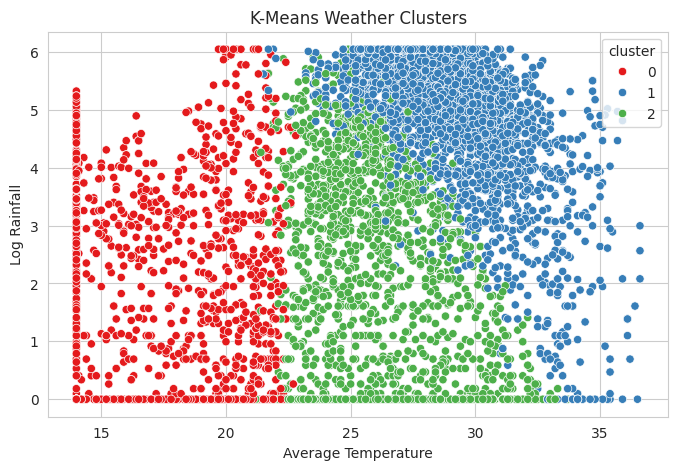

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tavg",
    y="prcp_log",
    hue="cluster",
    palette="Set1"
)

plt.title("K-Means Weather Clusters")
plt.xlabel("Average Temperature")
plt.ylabel("Log Rainfall")
plt.show()

# 13. Time Series Analysis: City-Wise Weather Trend


In [ ]:
city_name = "Mumbai"

city_df = df[df["city"] == city_name].copy()
city_df = city_df.sort_values("date")
city_df = city_df.set_index("date")

ts_data = city_df["tavg"]

print(ts_data.head())

date
2020-01-01    24.9
2020-02-01    27.3
2020-03-01    27.7
2020-04-01    30.2
2020-05-01    31.1
Name: tavg, dtype: float64


##13.1: Visualizing Historical Average Temperature

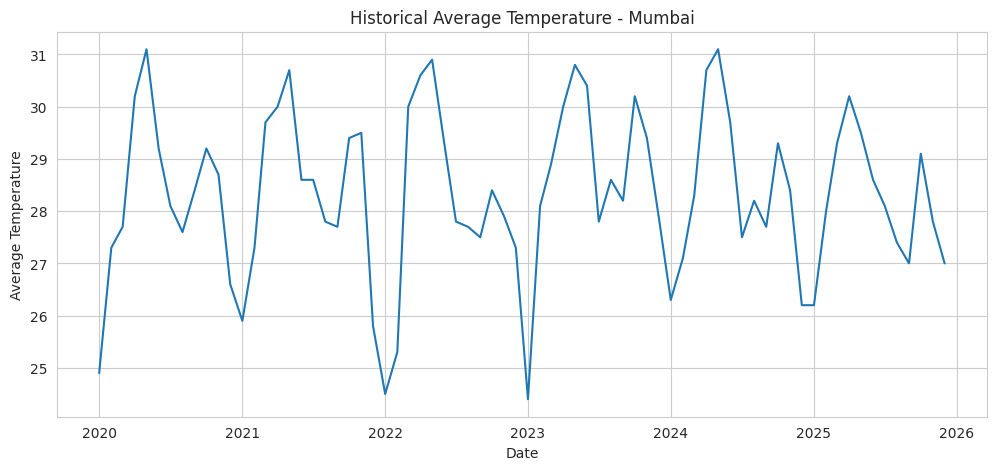

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(ts_data)

plt.title("Historical Average Temperature - " + city_name)
plt.xlabel("Date")
plt.ylabel("Average Temperature")
plt.show()

###13.2: Splitting Time Series Data into Train and Test Sets

In [ ]:
train_size = int(len(ts_data) * 0.8)

train = ts_data.iloc[:train_size]
test = ts_data.iloc[train_size:]

print("Train size:", train.shape)
print("Test size:", test.shape)

Train size: (57,)
Test size: (15,)


### 13.3: ARIMA Model Fitting

In [ ]:
arima_model = ARIMA(train, order=(1, 1, 1))
arima_result = arima_model.fit()
print(arima_result.summary())


                               SARIMAX Results                                
Dep. Variable:                   tavg   No. Observations:                   57
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -104.918
Date:                Mon, 25 May 2026   AIC                            215.836
Time:                        14:52:55   BIC                            221.912
Sample:                    01-01-2020   HQIC                           218.192
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0142      1.001     -0.014      0.989      -1.976       1.947
ma.L1          0.1834      0.999      0.184      0.854      -1.774       2.141
sigma2         2.4810      0.411      6.030      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

#### 13.3.1: Model Evaluation

In [ ]:
arima_prediction = arima_result.forecast(steps=len(test))

arima_mae = mean_absolute_error(test, arima_prediction)
arima_rmse = np.sqrt(mean_squared_error(test, arima_prediction))

print("ARIMA Results")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)

ARIMA Results
MAE: 1.1053622410198167
RMSE: 1.3021696386319652


#### 13.3.2: Visualizing ARIMA Actual vs. Predicted Temperature Trends

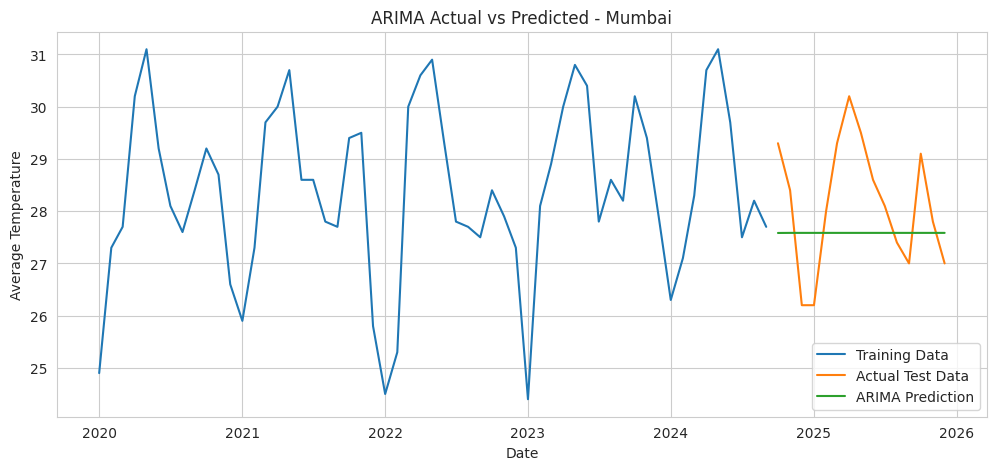

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data")
plt.plot(test.index, arima_prediction, label="ARIMA Prediction")

plt.title("ARIMA Actual vs Predicted - " + city_name)
plt.xlabel("Date")
plt.ylabel("Average Temperature")
plt.legend()
plt.show()

####13.3.3: Monthly ARIMA forecasts for 2026

In [ ]:
final_arima_model = ARIMA(ts_data, order=(1, 1, 1))
final_arima_result = final_arima_model.fit()

arima_forecast_2026 = final_arima_result.forecast(steps=12)

future_dates = pd.date_range(
    start="2026-01-01",
    periods=12,
    freq="MS"
)

arima_2026_df = pd.DataFrame({
    "date": future_dates,
    "city": city_name,
    "arima_predicted_tavg": arima_forecast_2026.values
})

print(arima_2026_df)

         date    city  arima_predicted_tavg
0  2026-01-01  Mumbai             26.929489
1  2026-02-01  Mumbai             26.932788
2  2026-03-01  Mumbai             26.932634
3  2026-04-01  Mumbai             26.932641
4  2026-05-01  Mumbai             26.932641
5  2026-06-01  Mumbai             26.932641
6  2026-07-01  Mumbai             26.932641
7  2026-08-01  Mumbai             26.932641
8  2026-09-01  Mumbai             26.932641
9  2026-10-01  Mumbai             26.932641
10 2026-11-01  Mumbai             26.932641
11 2026-12-01  Mumbai             26.932641


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

####13.3.4: Visualizing Final 2026 ARIMA Temperature Forecasts

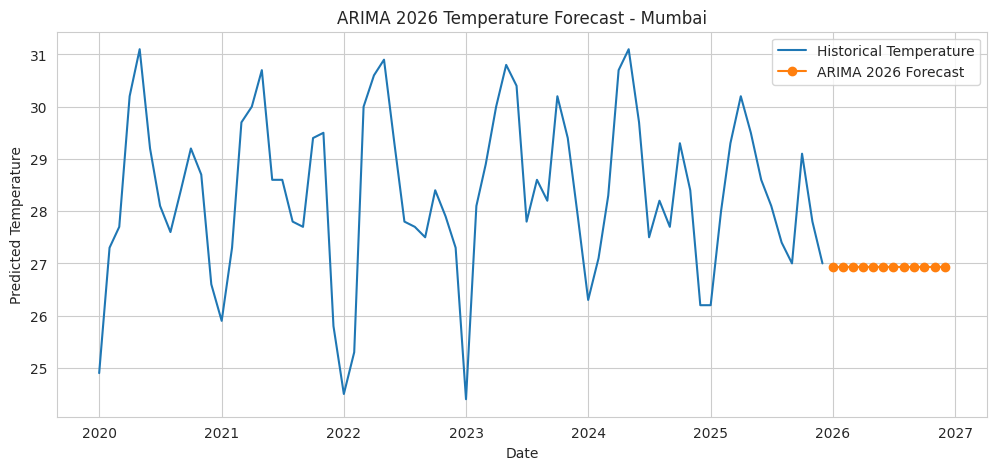

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(ts_data, label="Historical Temperature")

plt.plot(
    arima_2026_df["date"],
    arima_2026_df["arima_predicted_tavg"],
    marker="o",
    label="ARIMA 2026 Forecast"
)

plt.title("ARIMA 2026 Temperature Forecast - " + city_name)
plt.xlabel("Date")
plt.ylabel("Predicted Temperature")
plt.legend()
plt.show()

In [ ]:
df.to_csv("final_cleaned_weather_dataset.csv", index=False)
future_2026.to_csv("weather_prediction_2026_temperature_rainfall_classification.csv",index=False)
arima_2026_df.to_csv("arima_temperature_prediction_2026.csv", index=False)

print("All output files saved successfully.")

All output files saved successfully.
